# Automatic detection of Symmetry in the images HAM10000 based on shape 

In [1]:
#Instalar el paquete 
import zipfile
zipfile.ZipFile('dermoscopic_symmetry-master.zip').extractall('.')

In [2]:
#Preparar los datos, necesito DataImageRGB y binary_segmentation (máscara binaria de la lesión, 
#donde el área de interés es 1 (o True) y el fondo es 0)

In [3]:
import zipfile
import os
import cv2

# Archivos a extraer
zip_files = [
    "/home/marc/MARIADELMAR_EXPERIMENTS/HAM10000_images_part_1.zip",
    "/home/marc/MARIADELMAR_EXPERIMENTS/HAM10000_images_part_2.zip",
    "/home/marc/MARIADELMAR_EXPERIMENTS/HAM10000_segmentations_lesion_tschandl.zip"
]

# Destinos
images_folder = "/home/marc/MARIADELMAR_EXPERIMENTS/dataverse_files/images"
seg_folder = "/home/marc/MARIADELMAR_EXPERIMENTS/dataverse_files/binary_seg/HAM10000_segmentations_lesion_tschandl"

os.makedirs(images_folder, exist_ok=True)
os.makedirs(seg_folder, exist_ok=True)

for zip_path in zip_files:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        # Segmentaciones van a binary_seg, imágenes a images
        if "segmentations" in zip_path:
            zip_ref.extractall(seg_folder)
        else:
            zip_ref.extractall(images_folder)

print(f"Imágenes en: {images_folder}")
print(f"Máscaras en: {seg_folder}")

Imágenes en: /home/marc/MARIADELMAR_EXPERIMENTS/dataverse_files/images
Máscaras en: /home/marc/MARIADELMAR_EXPERIMENTS/dataverse_files/binary_seg/HAM10000_segmentations_lesion_tschandl


In [4]:
import os

# Definir la carpeta de segmentaciones (máscaras) y la imagen
seg_folder = "/home/marc/MARIADELMAR_EXPERIMENTS/dataverse_files/binary_seg/HAM10000_segmentations_lesion_tschandl"
filename = "ISIC_0024306.jpg"  # Este es un ejemplo de nombre de imagen


mask_path = os.path.join(seg_folder, filename.replace(".jpg", "_segmentation.png"))
# Verificar si la máscara existe
if os.path.exists(mask_path):
    print(f"La máscara existe en: {mask_path}")
else:
    print(f"¡La máscara no existe! Verifica la ruta: {mask_path}")


La máscara existe en: /home/marc/MARIADELMAR_EXPERIMENTS/dataverse_files/binary_seg/HAM10000_segmentations_lesion_tschandl/ISIC_0024306_segmentation.png


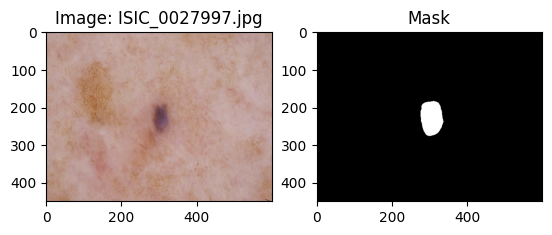

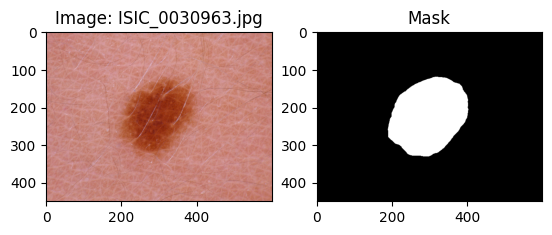

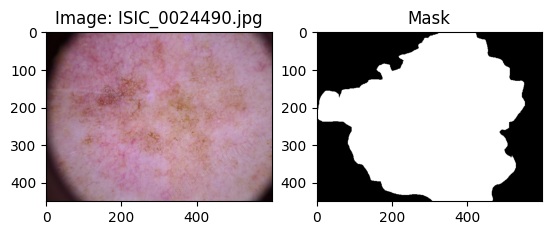

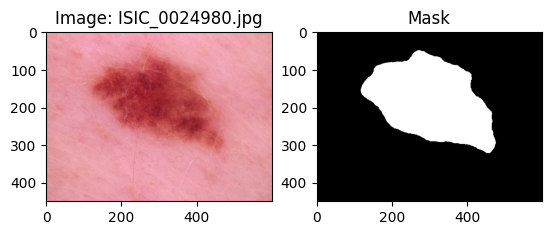

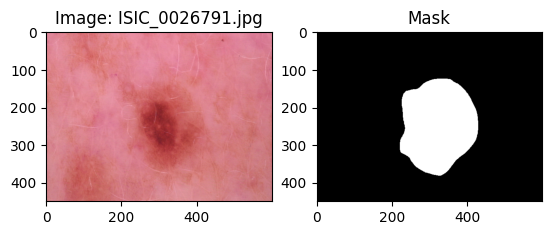

In [5]:
import os
import cv2
import matplotlib.pyplot as plt

images_folder = "/home/marc/MARIADELMAR_EXPERIMENTS/dataverse_files/images"
seg_folder = "/home/marc/MARIADELMAR_EXPERIMENTS/dataverse_files/binary_seg/HAM10000_segmentations_lesion_tschandl"

contador = 0

for filename in os.listdir(images_folder):
    if filename.endswith(".jpg"):
        image_path = os.path.join(images_folder, filename)
        mask_filename = filename.replace(".jpg", "_segmentation.png")
        mask_path = os.path.join(seg_folder, mask_filename)
        
        if os.path.exists(mask_path):
            image_bgr = cv2.imread(image_path)
            if image_bgr is not None:
                image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                
                if mask is not None and contador < 5:
                    plt.subplot(1, 2, 1)
                    plt.imshow(image_rgb)
                    plt.title(f'Image: {filename}')
                    
                    plt.subplot(1, 2, 2)
                    plt.imshow(mask, cmap='gray')
                    plt.title(f'Mask')
                    
                    plt.show()
                    contador += 1
                    
            if contador >= 5:
                break

In [6]:
file_path = './dermoscopic_symmetry-master/dermoscopic_symmetry/utils.py'

with open(file_path, 'r') as file:
    content = file.read()


content = content.replace('from skimage.draw import circle', 
                         'from skimage.draw import disk')
content = content.replace('circle(', 'disk(')  # Also fix function calls


with open(file_path, 'w') as file:
    file.write(content)

print("Fixed 'circle' import in utils.py")

Fixed 'circle' import in utils.py


In [7]:
import sys
sys.path.append('./dermoscopic_symmetry-master')

import cv2
import numpy as np
from pathlib import Path

from dermoscopic_symmetry.shape_symmetry import shape_symmetry

------------------------------------------------------------
CLASSIFYING HAM10000 DATASET (TEST - 100 images)
------------------------------------------------------------
Found 100 images
Processing images...
 Processed 10/100 images
 Processed 20/100 images
 Processed 30/100 images
 Processed 40/100 images
 Processed 50/100 images
 Processed 60/100 images
 Processed 70/100 images
 Processed 80/100 images
 Processed 90/100 images
 Processed 100/100 images

PROCESSING COMPLETED:
Results saved to CSV: /home/marc/MARIADELMAR_EXPERIMENTS/ham10000_TEST_100.csv
Successfully classified: 100 images
Failed or skipped: 0 images

All images processed successfully.

VISUALIZING FIRST 5 CLASSIFIED IMAGES:
------------------------------------------------------------

Image: ISIC_0027997
Symmetry classification data: [0, [176, 93.60670194003528], [86, 89.47368421052632]]


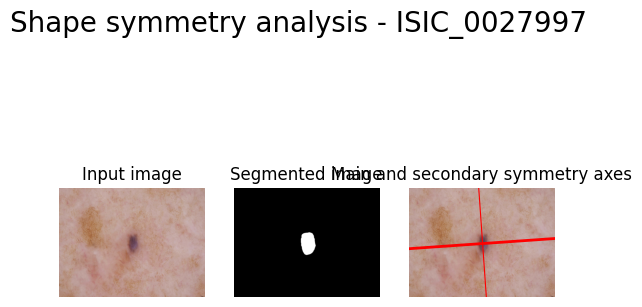


Image: ISIC_0030963
Symmetry classification data: [0, [46, 96.7512077294686], [136, 94.34421364985162]]


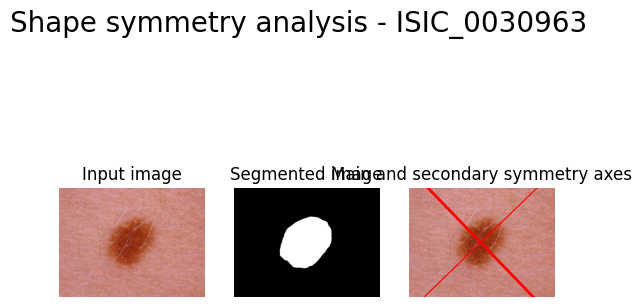


Image: ISIC_0024490
Symmetry classification data: [1, [55, 90.59283228524329], [None, None]]


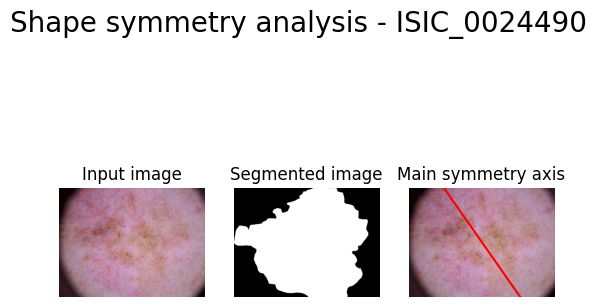


Image: ISIC_0024980
Symmetry classification data: [1, [115, 93.31824836949288], [None, None]]


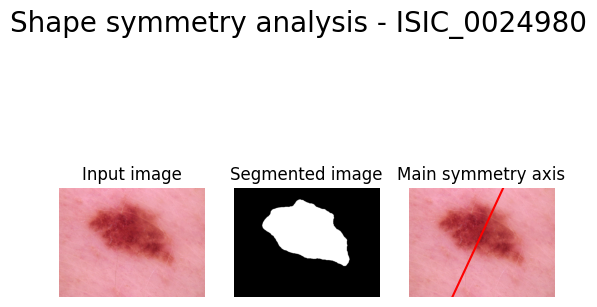


Image: ISIC_0026791
Symmetry classification data: [0, [0, 93.76265494592325], [90, 91.22798362030687]]


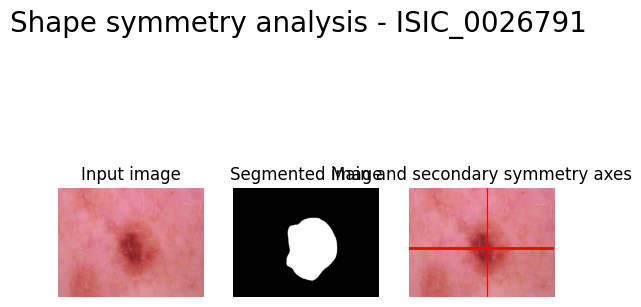

In [8]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt


# Import functions from the repository
from dermoscopic_symmetry.shape_symmetry_fixed import shape_symmetry
from dermoscopic_symmetry.utils import display_symmetry_axes
from dermoscopic_symmetry.shape_symmetry_fixed import shape_symmetry, shape_symmetry_ratios

# Configuration: Paths to your dataset
IMAGES_FOLDER = "/home/marc/MARIADELMAR_EXPERIMENTS/dataverse_files/images"
SEG_FOLDER = "/home/marc/MARIADELMAR_EXPERIMENTS/dataverse_files/binary_seg/HAM10000_segmentations_lesion_tschandl"

def my_load_segmentation(im_number):
    """Load segmentation mask for a HAM10000 image. Returns mask in 0-255 format."""
    mask_path = Path(SEG_FOLDER) / f"{im_number}_segmentation.png"
    if not mask_path.exists():
        mask_path = Path(SEG_FOLDER) / f"{im_number}.png"
    
    if mask_path.exists():
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if mask is not None:
            # Binarize: values above 127 become 255, others become 0
            _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
            return (binary > 0).astype(np.uint8)
# shape_symmetry expects 0-255 format
    return None

def my_load_dermoscopic(im_number):
    """Load original dermoscopic image for HAM10000. Returns RGB image."""
    # Try .jpg first, then .png
    img_path = Path(IMAGES_FOLDER) / f"{im_number}.jpg"
    if not img_path.exists():
        img_path = Path(IMAGES_FOLDER) / f"{im_number}.png"
    
    if img_path.exists():
        img = cv2.imread(str(img_path))
        if img is not None:
            # Convert from OpenCV's BGR to standard RGB for matplotlib
            return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return None

def classify_image(im_number):
    """Classify a single image using the shape_symmetry function from the repository."""
    # Load the original image
    dermoscopic = my_load_dermoscopic(im_number)
    
    # Load the corresponding segmentation mask
    segmentation = my_load_segmentation(im_number)
    
    #both image and mask must exist
    if segmentation is None or dermoscopic is None:
        return None, None, None
    
    # Check the mask is not completely empty
    if segmentation.max() == 0:
        return None, None, None
    
    #have at least 100 active (non-zero) pixels
    if np.sum(segmentation > 0) < 100:
        return None, None, None
    
    try:
        # Call the main symmetry analysis function from the repository
        symmetry_info = shape_symmetry(segmentation, angle_step=1)
        return dermoscopic, segmentation, symmetry_info
    except Exception as e:
        print(f"Error processing {im_number}: {e}")
        return None, None, None

print("-" * 60)
print("CLASSIFYING HAM10000 DATASET (TEST - 100 images)")
print("-" * 60)

# Get the first 100 image files from the images folder
image_files = list(Path(IMAGES_FOLDER).glob("*.jpg"))[:100]

image_names = [f.stem for f in image_files]

print(f"Found {len(image_names)} images")
print("Processing images...")

# Lists to store results and track failures
results = []
failed_images = []

# Main processing loop
for i, im_number in enumerate(image_names):
    # Classify current image
    dermoscopic, segmentation, symmetry_info = classify_image(im_number)
    
    if symmetry_info is not None:
        
        sym_class = symmetry_info[0] # 0,1,2,-1 
        
        # Primer eje (ya calculado por shape_symmetry) 
        ratios = shape_symmetry_ratios(segmentation, angle_step=1) 
        axis1_percent = max(ratios) if ratios else None

        # Segundo eje (puede ser None) 
        axis2_percent = symmetry_info[2][1] 
        results.append({ 'image': im_number, 
                        'shape_symmetry': sym_class, 
                        'axis1_percent': axis1_percent, 
                        'axis2_percent': axis2_percent 
        })
       
    else:
        # Failed classification: track image name
        failed_images.append(im_number)
    
    #Progress indicator every 10 images
    if (i + 1) % 10 == 0:
        print(f" Processed {i + 1}/{len(image_names)} images")

# Save results to CSV file
csv_filename = '/home/marc/MARIADELMAR_EXPERIMENTS/ham10000_TEST_100.csv'
df = pd.DataFrame(results)
df.to_csv(csv_filename, index=False)

print(f"\nPROCESSING COMPLETED:")
print(f"Results saved to CSV: {csv_filename}")
print(f"Successfully classified: {len(df)} images")
print(f"Failed or skipped: {len(failed_images)} images")

# Report failed images if any
if failed_images:
    print(f"\nFAILED/SKIPPED IMAGES ({len(failed_images)}):")
    print("=" * 40)
    
    # Show first 10 failures
    for failed in failed_images[:10]:
        print(f"  {failed}")
    
    # Indicate if there are more
    if len(failed_images) > 10:
        print(f"  ... and {len(failed_images) - 10} more")
else:
    print(f"\nAll images processed successfully.")

# Visualize results for the first few images
if len(results) > 0:
    print(f"\nVISUALIZING FIRST {min(5, len(results))} CLASSIFIED IMAGES:")
    print("-" * 60)
    
    num_to_show = min(5, len(results))
    
    for idx in range(num_to_show):
        im_number = results[idx]['image']
        # Reload data for visualization
        dermoscopic, segmentation, symmetry_info = classify_image(im_number)
        
        if dermoscopic is not None:
            print(f"\nImage: {im_number}")
            print(f"Symmetry classification data: {symmetry_info}")
            
            # Use the repository's visualization function
            # This shows: original image, mask, and symmetry axes in one figure
            display_symmetry_axes(
                dermoscopic, 
                segmentation,  # Already in 0-255 format
                symmetry_info,
                title=f'Shape symmetry analysis - {im_number}'
            )

            
# En shape_symmetry_fixed.py:
#highThresh = 92    # >92% = Buena simetría
#lowThresh = 90     # <90% = Asimétrica

In [9]:
#visualizacion de la clasificación en imágenes sencillas
import numpy as np
import cv2
import matplotlib.pyplot as plt

def create_square(size=256, margin=40):
    img = np.zeros((size, size), dtype=np.uint8)
    cv2.rectangle(img, (margin, margin), (size-margin, size-margin), 255, -1)
    return (img > 0).astype(np.uint8)

def create_rectangle(size=256, w=150, h=80):
    img = np.zeros((size, size), dtype=np.uint8)
    x1 = (size - w) // 2
    y1 = (size - h) // 2
    cv2.rectangle(img, (x1, y1), (x1+w, y1+h), 255, -1)
    return (img > 0).astype(np.uint8)

def create_circle(size=256, radius=80):
    img = np.zeros((size, size), dtype=np.uint8)
    cv2.circle(img, (size//2, size//2), radius, 255, -1)
    return (img > 0).astype(np.uint8)

def create_triangle(size=256): #isósceles
    img = np.zeros((size, size), dtype=np.uint8)
    pts = np.array([
        [size//2, 40],
        [40, size-40],
        [size-40, size-40]
    ], np.int32)
    cv2.fillPoly(img, [pts], 255)
    return (img > 0).astype(np.uint8)

def create_equilateral_triangle(size=256):
    img = np.zeros((size, size), dtype=np.uint8)

    side = int(size * 0.7)
    h = int((np.sqrt(3) / 2) * side)

    cx = size // 2
    cy = size // 2

    p1 = (cx, cy - h // 2)
    p2 = (cx - side // 2, cy + h // 2)
    p3 = (cx + side // 2, cy + h // 2)

    pts = np.array([p1, p2, p3], np.int32)
    cv2.fillPoly(img, [pts], 255)

    return (img > 0).astype(np.uint8)




SQUARE
Symmetry class: 0
Main axis: 0 coef: 98.87640449438202
Second axis: 90 coef: 97.3274224192527


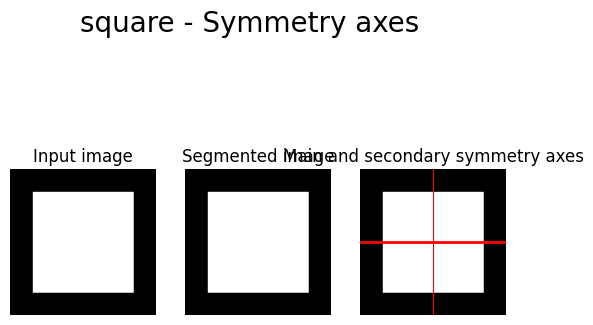


RECTANGLE
Symmetry class: 0
Main axis: 91 coef: 98.68421052631578
Second axis: 1 coef: 97.5609756097561


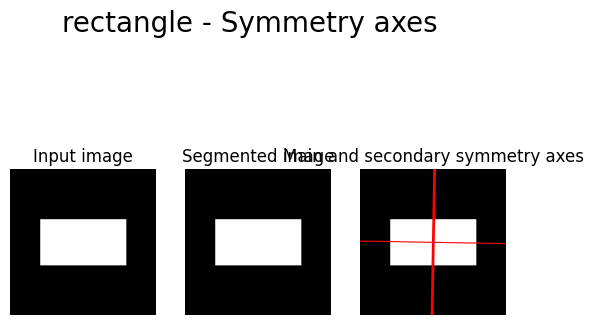


CIRCLE
Symmetry class: 0
Main axis: 0 coef: 98.40924809801403
Second axis: 90 coef: 97.8031721012708


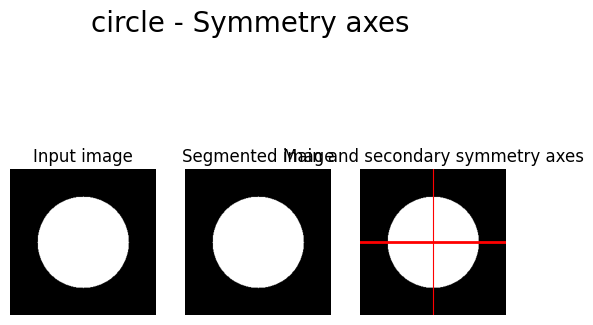


ISOSCELES_TRIANGLE
Symmetry class: 1
Main axis: 91 coef: 97.78998626545136
Second axis: None coef: None


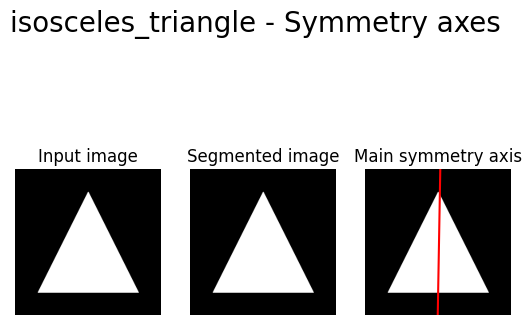


EQUILATERAL_TRIANGLE
Symmetry class: 1
Main axis: 151 coef: 97.21554770318022
Second axis: None coef: None


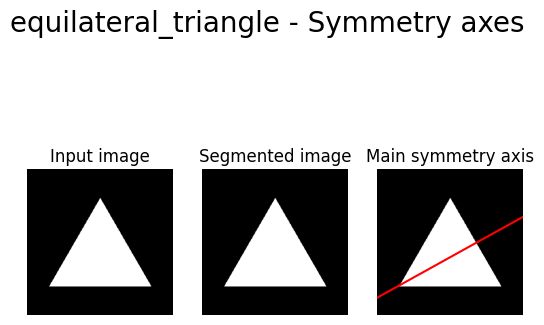

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import regionprops
from dermoscopic_symmetry.utils import display_symmetry_axes

shapes = {
    "square": create_square(),
    "rectangle": create_rectangle(),
    "circle": create_circle(),
    "isosceles_triangle": create_triangle(),
    "equilateral_triangle": create_equilateral_triangle()
}

for name, mask in shapes.items():
    symmetry_info = shape_symmetry(mask, angle_step=1)
    
    angle_main = symmetry_info[1][0]
    main_coef = symmetry_info[1][1]
    angle_second = symmetry_info[2][0]
    second_coef = symmetry_info[2][1]
    
    print(f"\n{name.upper()}")
    print(f"Symmetry class: {symmetry_info[0]}")
    print(f"Main axis: {angle_main} coef: {main_coef}")
    print(f"Second axis: {angle_second} coef: {second_coef}")
    
    
    mask_display = (mask * 255).astype(np.uint8)
    
    display_symmetry_axes(
        img=mask_display,  
        segmentation=mask.astype(np.uint8) * 255,  # También en 0-255
        symmetry_info=symmetry_info,
        title=f'{name} - Symmetry axes'
    )

------------------------------------------------------------
CLASSIFYING HAM10000 DATASET (ALL images)
------------------------------------------------------------
Found 10015 images
Processing images...

[VIS] Image: ISIC_0024306
Symmetry classification data: [1, [77, 90.13603263074722], [None, None]]
Axis1 %: 90.13603263074722
Axis2 %: None


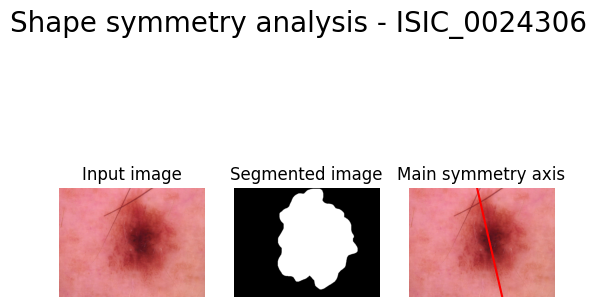


[VIS] Image: ISIC_0024307
Symmetry classification data: [0, [127, 93.89409094133504], [37, 91.4175421278996]]
Axis1 %: 93.89409094133504
Axis2 %: 91.4175421278996


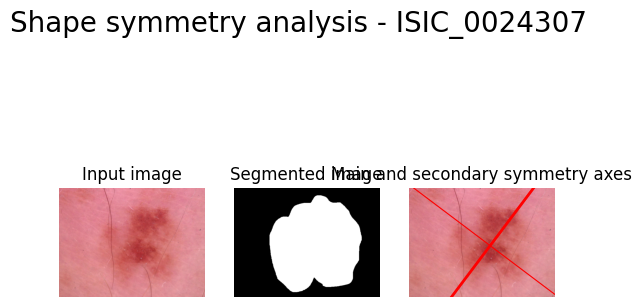


[VIS] Image: ISIC_0024308
Symmetry classification data: [0, [125, 94.07691233111817], [35, 92.87953337036743]]
Axis1 %: 94.07691233111817
Axis2 %: 92.87953337036743


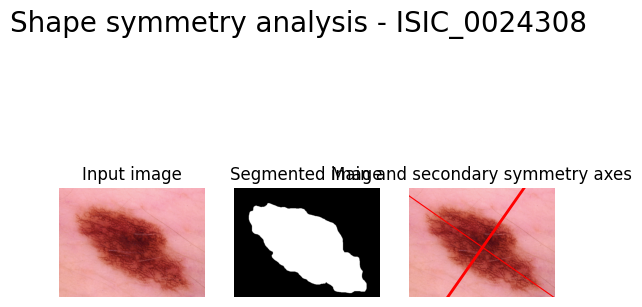


[VIS] Image: ISIC_0024309
Symmetry classification data: [2, [None, None], [None, None]]
Axis1 %: 88.4050769198915
Axis2 %: None


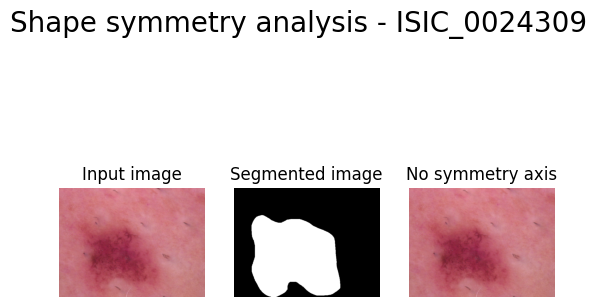


[VIS] Image: ISIC_0024310
Symmetry classification data: [2, [None, None], [None, None]]
Axis1 %: 83.89678115446863
Axis2 %: None


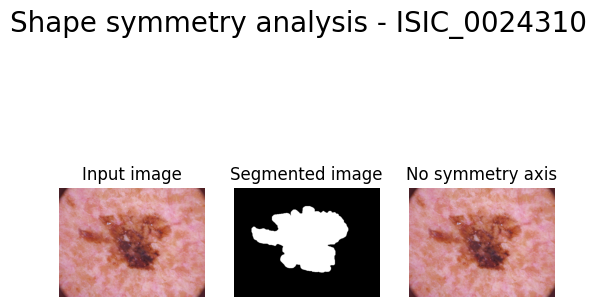

 Processed 500/10015 images
 Processed 1000/10015 images
 Processed 1500/10015 images
 Processed 2000/10015 images
 Processed 2500/10015 images
 Processed 3000/10015 images
 Processed 3500/10015 images
 Processed 4000/10015 images
 Processed 4500/10015 images
 Processed 5000/10015 images
 Processed 5500/10015 images
 Processed 6000/10015 images
 Processed 6500/10015 images
 Processed 7000/10015 images
 Processed 7500/10015 images
 Processed 8000/10015 images
 Processed 8500/10015 images
 Processed 9000/10015 images
 Processed 9500/10015 images
 Processed 10000/10015 images
 Processed 10015/10015 images

Total processing time: 125471.84 seconds
Average time per image: 12.5284 seconds

------------------------------------------------------------
PROCESSING COMPLETED
------------------------------------------------------------
Results saved to CSV: /home/marc/MARIADELMAR_EXPERIMENTS/ham10000_shape_symmetry_ALL.csv
Successfully classified: 10015 images
Failed or skipped: 0 images

All imag

In [12]:
# Same process but all images
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import time  

# Import functions from the repository
from dermoscopic_symmetry.shape_symmetry_fixed import shape_symmetry, shape_symmetry_ratios
from dermoscopic_symmetry.utils import display_symmetry_axes

# Configuration: Paths to your dataset
IMAGES_FOLDER = "/home/marc/MARIADELMAR_EXPERIMENTS/dataverse_files/images"
SEG_FOLDER = "/home/marc/MARIADELMAR_EXPERIMENTS/dataverse_files/binary_seg/HAM10000_segmentations_lesion_tschandl"

# Output
FINAL_CSV = "/home/marc/MARIADELMAR_EXPERIMENTS/ham10000_shape_symmetry_ALL.csv"

PROGRESS_EVERY = 500
VISUALIZE_N = 5   #show only a few total


def my_load_segmentation(im_number):
    """Load segmentation mask for a HAM10000 image. Returns mask in 0-255 format."""
    mask_path = Path(SEG_FOLDER) / f"{im_number}_segmentation.png"
    if not mask_path.exists():
        mask_path = Path(SEG_FOLDER) / f"{im_number}.png"

    if mask_path.exists():
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        if mask is not None:
            _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
            return (binary > 0).astype(np.uint8)

    return None


def my_load_dermoscopic(im_number):
    """Load original dermoscopic image for HAM10000. Returns RGB image."""
    img_path = Path(IMAGES_FOLDER) / f"{im_number}.jpg"
    if not img_path.exists():
        img_path = Path(IMAGES_FOLDER) / f"{im_number}.png"

    if img_path.exists():
        img = cv2.imread(str(img_path))
        if img is not None:
            return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return None


def classify_image(im_number):
    """Classify a single image using shape_symmetry."""
    dermoscopic = my_load_dermoscopic(im_number)
    segmentation = my_load_segmentation(im_number)

    if segmentation is None or dermoscopic is None:
        return None, None, None

    if segmentation.max() == 0:
        return None, None, None

    if np.sum(segmentation > 0) < 100:
        return None, None, None

    try:
        symmetry_info = shape_symmetry(segmentation, angle_step=1)
        return dermoscopic, segmentation, symmetry_info
    except Exception as e:
        print(f"Error processing {im_number}: {e}")
        return None, None, None


print("-" * 60)
print("CLASSIFYING HAM10000 DATASET (ALL images)")
print("-" * 60)

image_files = list(Path(IMAGES_FOLDER).glob("*.jpg")) + list(Path(IMAGES_FOLDER).glob("*.png"))
image_names = sorted({f.stem for f in image_files})

total_images = len(image_names)
print(f"Found {total_images} images")
print("Processing images...")

results = []
failed_images = []
visualized = 0

# Start timer
start_time = time.time()

for i, im_number in enumerate(image_names):
    dermoscopic, segmentation, symmetry_info = classify_image(im_number)

    if symmetry_info is not None:

        # Clase de simetría (0,1,2,-1)
        sym_class = symmetry_info[0]

        # Primer eje: porcentaje máximo de simetría
        ratios = shape_symmetry_ratios(segmentation, angle_step=1)
        axis1_percent = max(ratios) if ratios else None

        # Segundo eje (puede ser None)
        axis2_percent = None
        if symmetry_info[2] is not None:
            axis2_percent = symmetry_info[2][1]

        # Guardar resultados completos
        results.append({
            "image": im_number,
            "shape_symmetry": sym_class,
            "axis1_percent": axis1_percent,
            "axis2_percent": axis2_percent
        })

        # Visualización opcional
        if visualized < VISUALIZE_N:
            print(f"\n[VIS] Image: {im_number}")
            print(f"Symmetry classification data: {symmetry_info}")
            print(f"Axis1 %: {axis1_percent}")
            print(f"Axis2 %: {axis2_percent}")

            display_symmetry_axes(
                dermoscopic,
                segmentation,
                symmetry_info,
                title=f"Shape symmetry analysis - {im_number}"
            )
            visualized += 1

    else:
        failed_images.append(im_number)

    # Progress indicator every 500 images
    if (i + 1) % PROGRESS_EVERY == 0 or (i + 1) == total_images:
        print(f" Processed {i + 1}/{total_images} images")

# End timer
end_time = time.time()
total_time = end_time - start_time
avg_time = total_time / total_images

print(f"\nTotal processing time: {total_time:.2f} seconds")
print(f"Average time per image: {avg_time:.4f} seconds")

# Save final CSV
df = pd.DataFrame(results)
df.to_csv(FINAL_CSV, index=False)

print("\n" + "-" * 60)
print("PROCESSING COMPLETED")
print("-" * 60)
print(f"Results saved to CSV: {FINAL_CSV}")
print(f"Successfully classified: {len(df)} images")
print(f"Failed or skipped: {len(failed_images)} images")

if failed_images:
    print(f"\nFAILED/SKIPPED IMAGES ({len(failed_images)}):")
    print("=" * 40)
    for failed in failed_images[:20]:
        print(f"  {failed}")
    if len(failed_images) > 20:
        print(f"  ... and {len(failed_images) - 20} more")
else:
    print("\nAll images processed successfully.")

# Notes:
# En shape_symmetry_fixed.py:
# highThresh = 92    # >92% = Buena simetría
# lowThresh = 90     # <90% = Asimétrica
#angle principal linea toja más gruesa
#añadir llindar, que pasa con las de en medio
#hacer las dos, en multitask tener la clasificacionde simetria y añadir metricas de simetria